# HW4 Bonus: Fine-tuning Cross-Encoder on WikIR

## 0. Установка зависимостей

In [1]:
!pip install -q sentence-transformers transformers rank_bm25 ir-datasets datasets scikit-learn tqdm pandas numpy matplotlib accelerate

In [2]:
import random
import numpy as np
import pandas as pd
import torch
import re
import gc
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 1. Загрузка данных

### 1.1 WikIR (en1k)

In [3]:
import ir_datasets

def load_wikir(train_id='wikir/en1k/training', test_id='wikir/en1k/test'):
    train_ds = ir_datasets.load(train_id)
    test_ds  = ir_datasets.load(test_id)

    print('Loading corpus...')
    corpus = {doc.doc_id: doc.text for doc in train_ds.docs_iter()}
    print(f'Corpus: {len(corpus)} docs')

    train_queries = {q.query_id: q.text for q in train_ds.queries_iter()}
    test_queries  = {q.query_id: q.text for q in test_ds.queries_iter()}
    print(f'Train queries: {len(train_queries)}, Test queries: {len(test_queries)}')

    def load_qrels(ds):
        qrels = {}
        for qrel in ds.qrels_iter():
            qrels.setdefault(qrel.query_id, {})[qrel.doc_id] = qrel.relevance
        return qrels

    train_qrels = load_qrels(train_ds)
    test_qrels  = load_qrels(test_ds)
    print(f'Train qrels: {len(train_qrels)} queries, Test qrels: {len(test_qrels)} queries')
    return corpus, train_queries, test_queries, train_qrels, test_qrels

wikir_corpus, wikir_train_q, wikir_test_q, wikir_train_qrels, wikir_test_qrels = load_wikir()

Loading corpus...


[INFO] If you have a local copy of https://zenodo.org/record/3565761/files/wikIR1k.zip, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/554299bca984640cb283d6ba55753608
[INFO] [starting] https://zenodo.org/record/3565761/files/wikIR1k.zip
[INFO] [finished] https://zenodo.org/record/3565761/files/wikIR1k.zip: [00:05] [165MB] [28.5MB/s]


Corpus: 369721 docs
Train queries: 1444, Test queries: 100
Train qrels: 1444 queries, Test qrels: 100 queries


In [4]:
def subsample_corpus(corpus, qrels, max_docs=50000, seed=42):
    """Все релевантные документы + случайные до max_docs."""
    random.seed(seed)
    relevant_ids = {did for qrel in qrels.values() for did in qrel}
    other_ids = [did for did in corpus if did not in relevant_ids]
    random.shuffle(other_ids)
    keep = relevant_ids | set(other_ids[:max_docs - len(relevant_ids)])
    return {did: corpus[did] for did in keep}

wikir_corpus_exp       = subsample_corpus(wikir_corpus, wikir_test_qrels,  max_docs=50000)
wikir_corpus_train_exp = subsample_corpus(wikir_corpus, wikir_train_qrels, max_docs=50000)

print(f'Full corpus:      {len(wikir_corpus)}')
print(f'Test subset:      {len(wikir_corpus_exp)}')
print(f'Train subset:     {len(wikir_corpus_train_exp)}')

Full corpus:      369721
Test subset:      50000
Train subset:     50000


### 1.2 MIRAGE

In [5]:
from datasets import load_dataset

mirage_ds = load_dataset('nlpai-lab/MIRAGE')

def build_mirage_structures(ds):
    data = ds['train']
    corpus, queries, qrels = {}, {}, {}
    for row in data:
        qid = str(row['query_id'])
        queries[qid] = row['query']
        pool_ids      = row['doc_pool']['mapped_id']
        pool_chunks   = row['doc_pool']['doc_chunk']
        pool_supports = row['doc_pool']['support']
        qrels[qid] = {}
        for i, (mid, chunk, support) in enumerate(zip(pool_ids, pool_chunks, pool_supports)):
            doc_id = f"{mid}__{i}"
            corpus[doc_id] = chunk
            if mid == qid and support == 1:
                qrels[qid][doc_id] = 1
    print(f'MIRAGE: {len(queries)} queries, {len(corpus)} docs')
    return corpus, queries, qrels

mirage_corpus, mirage_test_q, mirage_test_qrels = build_mirage_structures(mirage_ds)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7560 [00:00<?, ? examples/s]

MIRAGE: 7560 queries, 37800 docs


## 2. Метрики

In [6]:
def precision_at_k(ranked_docs, qrels, k):
    top_k = ranked_docs[:k]
    hits = sum(1 for d in top_k if qrels.get(d, 0) > 0)
    return hits / k

def average_precision_at_k(ranked_docs, qrels, k):
    top_k = ranked_docs[:k]
    hits, sum_prec = 0, 0.0
    for i, doc in enumerate(top_k, 1):
        if qrels.get(doc, 0) > 0:
            hits += 1
            sum_prec += hits / i
    if hits == 0:
        return 0.0
    n_rel = sum(1 for v in qrels.values() if v > 0)
    return sum_prec / min(k, n_rel) if n_rel > 0 else 0.0

def ndcg_at_k(ranked_docs, qrels, k):
    top_k = ranked_docs[:k]
    dcg = sum(qrels.get(doc, 0) / np.log2(i + 1) for i, doc in enumerate(top_k, 1))
    ideal_rels = sorted(qrels.values(), reverse=True)[:k]
    idcg = sum(rel / np.log2(i + 1) for i, rel in enumerate(ideal_rels, 1))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_run(run, all_qrels, ks=(1, 10, 20)):
    metrics = defaultdict(list)
    for qid, ranked in run.items():
        qrel = all_qrels.get(qid, {})
        if not qrel:
            continue
        ranked_docs = [doc_id for doc_id, _ in ranked]
        for k in ks:
            metrics[f'P@{k}'].append(precision_at_k(ranked_docs, qrel, k))
        metrics['MAP@20'].append(average_precision_at_k(ranked_docs, qrel, 20))
        metrics['nDCG@20'].append(ndcg_at_k(ranked_docs, qrel, 20))
    return {m: float(np.mean(v)) for m, v in metrics.items()}

METRICS_ORDER = ['P@1', 'P@10', 'P@20', 'MAP@20', 'nDCG@20']

def print_metrics(name, metrics):
    print(f'\n=== {name} ===')
    for m in METRICS_ORDER:
        if m in metrics:
            print(f'  {m}: {metrics[m]:.4f}')

## 3. BM25 для получения кандидатов

In [7]:
from rank_bm25 import BM25Okapi

def tokenize(text):
    return re.findall(r'\w+', text.lower())

def build_bm25_index(corpus):
    doc_ids = list(corpus.keys())
    tokenized = [tokenize(corpus[did]) for did in tqdm(doc_ids, desc='BM25 tokenize')]
    return BM25Okapi(tokenized), doc_ids

def bm25_search(bm25, doc_ids, query, top_k=100):
    scores = bm25.get_scores(tokenize(query))
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(doc_ids[i], float(scores[i])) for i in top_indices]

def run_bm25(corpus, queries, top_k=100):
    bm25, doc_ids = build_bm25_index(corpus)
    run = {qid: bm25_search(bm25, doc_ids, qtext, top_k=top_k)
           for qid, qtext in tqdm(queries.items(), desc='BM25 search')}
    return run, bm25, doc_ids

In [8]:
print('Building BM25 for WikIR test...')
wikir_bm25_run, wikir_bm25_obj, wikir_doc_ids = run_bm25(wikir_corpus_exp, wikir_test_q, top_k=100)

print('Building BM25 for WikIR train...')
wikir_bm25_train_obj, wikir_doc_ids_train = build_bm25_index(wikir_corpus_train_exp)
wikir_bm25_train_run = {
    qid: bm25_search(wikir_bm25_train_obj, wikir_doc_ids_train, qtext, top_k=100)
    for qid, qtext in tqdm(wikir_train_q.items(), desc='BM25 train search')
}

Building BM25 for WikIR test...


BM25 tokenize:   0%|          | 0/50000 [00:00<?, ?it/s]

BM25 search:   0%|          | 0/100 [00:00<?, ?it/s]

Building BM25 for WikIR train...


BM25 tokenize:   0%|          | 0/50000 [00:00<?, ?it/s]

BM25 train search:   0%|          | 0/1444 [00:00<?, ?it/s]

In [9]:
print('Building BM25 for MIRAGE...')
mirage_bm25_run, mirage_bm25_obj, mirage_doc_ids = run_bm25(mirage_corpus, mirage_test_q, top_k=100)

wikir_bm25_metrics = evaluate_run(wikir_bm25_run, wikir_test_qrels)
print_metrics('WikIR BM25 (test)', wikir_bm25_metrics)
mirage_bm25_metrics = evaluate_run(mirage_bm25_run, mirage_test_qrels)
print_metrics('MIRAGE BM25 (test)', mirage_bm25_metrics)

Building BM25 for MIRAGE...


BM25 tokenize:   0%|          | 0/37800 [00:00<?, ?it/s]

BM25 search:   0%|          | 0/7560 [00:00<?, ?it/s]


=== WikIR BM25 (test) ===
  P@1: 0.8100
  P@10: 0.3810
  P@20: 0.2635
  MAP@20: 0.3514
  nDCG@20: 0.5586

=== MIRAGE BM25 (test) ===
  P@1: 0.4865
  P@10: 0.0884
  P@20: 0.0472
  MAP@20: 0.5626
  nDCG@20: 0.6233


## 4. Подготовка обучающих пар для fine-tuning

**Стратегия формирования негативов:** Hard negatives из BM25 top-100.

Для каждого запроса берём все релевантные документы как позитивы (label=1)  
и сэмплируем `neg_per_pos` нерелевантных документов из BM25 top-100 как hard negatives (label=0).

In [ ]:
def build_training_pairs(
    queries, corpus, qrels, bm25_run,
    neg_per_pos=3, max_doc_len=512, seed=42
):
    """
    Формирует список (query_text, doc_text, label) для обучения cross-encoder.

    Позитивы: все документы из qrels[qid] с relevance > 0
    Негативы: negatives из BM25 top-100, не входящие в qrels
    """
    rng = random.Random(seed)
    pairs = []

    for qid, qtext in tqdm(queries.items(), desc='Building pairs'):
        qrel = qrels.get(qid, {})
        positive_ids = [did for did, rel in qrel.items() if rel > 0]
        if not positive_ids:
            continue

        bm25_candidates = [did for did, _ in bm25_run.get(qid, [])]
        hard_neg_ids = [did for did in bm25_candidates if qrel.get(did, 0) == 0]

        for pos_id in positive_ids:
            pos_text = corpus.get(pos_id, '')
            if not pos_text.strip():
                continue
            pairs.append((qtext, pos_text[:max_doc_len], 1))

            n_neg = min(neg_per_pos, len(hard_neg_ids))
            sampled_negs = rng.sample(hard_neg_ids, n_neg) if n_neg > 0 else []
            for neg_id in sampled_negs:
                neg_text = corpus.get(neg_id, '')
                if neg_text.strip():
                    pairs.append((qtext, neg_text[:max_doc_len], 0))

    rng.shuffle(pairs)
    pos_count = sum(1 for _, _, l in pairs if l == 1)
    neg_count = len(pairs) - pos_count
    print(f'Total pairs: {len(pairs)} (pos: {pos_count}, neg: {neg_count}, ratio: 1:{neg_count/max(pos_count,1):.1f})')
    return pairs


train_pairs = build_training_pairs(
    wikir_train_q,
    wikir_corpus,  
    wikir_train_qrels,
    wikir_bm25_train_run,
    neg_per_pos=3,
    max_doc_len=512
)

Building pairs:   0%|          | 0/1444 [00:00<?, ?it/s]

Total pairs: 190796 (pos: 47699, neg: 143097, ratio: 1:3.0)


In [12]:
print(f'\nПример позитивной пары:')
pos_example = next((p for p in train_pairs if p[2] == 1), None)
if pos_example:
    print(f'  Query: {pos_example[0][:80]}...')
    print(f'  Doc:   {pos_example[1][:80]}...')
    print(f'  Label: {pos_example[2]}')


Пример позитивной пары:
  Query: lakota language...
  Doc:   the population was 660 at the 2010 census new underwood had its start around 190...
  Label: 1


In [13]:
print(f'\nПример негативной пары:')
neg_example = next((p for p in train_pairs if p[2] == 0), None)
if neg_example:
    print(f'  Query: {neg_example[0][:80]}...')
    print(f'  Doc:   {neg_example[1][:80]}...')
    print(f'  Label: {neg_example[2]}')


Пример негативной пары:
  Query: cold war...
  Doc:   after the war stringfellow married green and became an episcopal minister shortl...
  Label: 0


## 5. Fine-tuning Cross-Encoder

**Конфигурация обучения:**
- Базовая модель: `cross-encoder/ms-marco-MiniLM-L-6-v2`
- Loss: Binary Cross-Entropy
- Оптимизатор: AdamW, lr=2e-5, weight decay=0.01
- Scheduler: linear warmup (10% шагов) → linear decay
- Batch size: 32 
- Epochs: 3
- Max sequence length: 512
- Gradient clipping: 1.0

In [ ]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
import os


BASE_MODEL      = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
MAX_SEQ_LEN     = 512
BATCH_SIZE      = 32
GRAD_ACCUM      = 2 
LEARNING_RATE   = 2e-5
WEIGHT_DECAY    = 0.01
NUM_EPOCHS      = 3
WARMUP_RATIO    = 0.1
MAX_GRAD_NORM   = 1.0
SAVE_DIR        = './finetuned_crossencoder'

In [ ]:
class CrossEncoderDataset(Dataset):
    """
    Датасет для cross-encoder: пары (query, doc) с бинарными метками.
    """
    def __init__(self, pairs, tokenizer, max_length=512):
        self.pairs      = pairs
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        query, doc, label = self.pairs[idx]
        encoding = self.tokenizer(
            query, doc,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'token_type_ids': encoding.get('token_type_ids', torch.zeros(self.max_length, dtype=torch.long)).squeeze(0),
            'label':          torch.tensor(label, dtype=torch.float)
        }

In [16]:
print(f'Loading tokenizer and model: {BASE_MODEL}')
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=1)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

Loading tokenizer and model: cross-encoder/ms-marco-MiniLM-L-6-v2


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

2026-04-24 12:36:32.062442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777034192.253275     153 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777034192.312281     153 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777034192.777230     153 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777034192.777254     153 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777034192.777257     153 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Model parameters: 22,713,601


In [17]:
dataset = CrossEncoderDataset(train_pairs, tokenizer, max_length=MAX_SEQ_LEN)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device == 'cuda')
)

total_steps    = (len(dataloader) // GRAD_ACCUM) * NUM_EPOCHS
warmup_steps   = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
loss_fn = torch.nn.BCEWithLogitsLoss()

print(f'Dataset size:   {len(dataset):,}')
print(f'Steps per epoch: {len(dataloader)}')
print(f'Total opt steps: {total_steps} (warmup: {warmup_steps})')

Dataset size:   190,796
Steps per epoch: 5963
Total opt steps: 8943 (warmup: 894)


In [ ]:
train_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(dataloader, desc=f'Epoch {epoch}/{NUM_EPOCHS}')
    for step, batch in enumerate(pbar, 1):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        logits = outputs.logits.squeeze(-1) 
        loss   = loss_fn(logits, labels) / GRAD_ACCUM
        loss.backward()
        epoch_loss += loss.item() * GRAD_ACCUM

        if step % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        pbar.set_postfix({'loss': f'{epoch_loss / step:.4f}',
                          'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch}: avg loss = {avg_loss:.4f}')

# Сохраняем модель
os.makedirs(SAVE_DIR, exist_ok=True)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'\nModel saved to {SAVE_DIR}')

Epoch 1/3:   0%|          | 0/5963 [00:00<?, ?it/s]

Epoch 1: avg loss = 0.3680


Epoch 2/3:   0%|          | 0/5963 [00:00<?, ?it/s]

Epoch 2: avg loss = 0.1798


Epoch 3/3:   0%|          | 0/5963 [00:00<?, ?it/s]

Epoch 3: avg loss = 0.1406

Model saved to ./finetuned_crossencoder


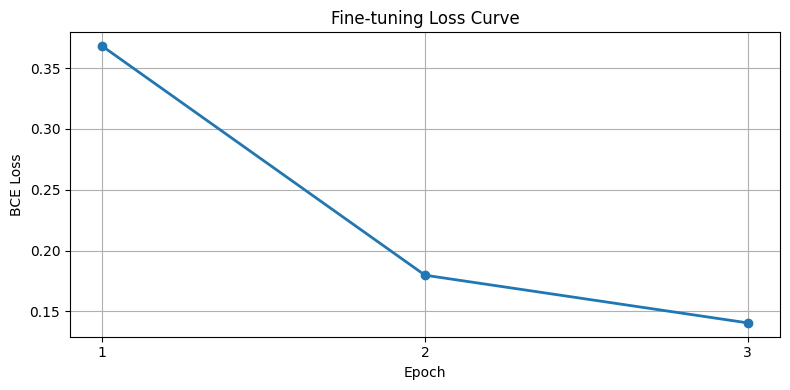

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Fine-tuning Loss Curve')
plt.xticks(range(1, NUM_EPOCHS + 1))
plt.grid(True)
plt.tight_layout()
plt.savefig('finetuning_loss.png', dpi=150)
plt.show()

## 6. Re-ranking с обученной моделью

BM25 извлекает top-k кандидатов, fine-tuned cross-encoder их ранжирует.

In [ ]:
from sentence_transformers import CrossEncoder

ft_ce = CrossEncoder(SAVE_DIR, device=device, max_length=MAX_SEQ_LEN)
print('Fine-tuned CrossEncoder loaded.')

baseline_ce = CrossEncoder(BASE_MODEL, device=device, max_length=MAX_SEQ_LEN)
print('Baseline CrossEncoder loaded.')

Fine-tuned CrossEncoder loaded.
Baseline CrossEncoder loaded.


In [21]:
def rerank_with_crossencoder(ce_model, queries, corpus, bm25_run, rerank_k=100, batch_size=256):
    """
    Re-ranking: берём top-rerank_k из bm25_run, скорим cross-encoder, переранжируем.
    """
    run = {}
    for qid, qtext in tqdm(queries.items(), desc=f'Re-rank k={rerank_k}'):
        top_docs = bm25_run.get(qid, [])[:rerank_k]
        if not top_docs:
            run[qid] = []
            continue
        doc_ids   = [d for d, _ in top_docs]
        doc_texts = [corpus.get(did, '') for did in doc_ids]
        pairs     = [(qtext, dt) for dt in doc_texts]
        scores    = ce_model.predict(pairs, batch_size=batch_size, show_progress_bar=False)
        ranked    = sorted(zip(doc_ids, scores.tolist()), key=lambda x: x[1], reverse=True)
        run[qid]  = [(did, float(sc)) for did, sc in ranked]
    return run

In [ ]:
RERANK_K_VALUES = [10, 50, 100]
results = {} 

results['BM25'] = {
    'WikIR':  wikir_bm25_metrics,
    'MIRAGE': mirage_bm25_metrics
}

In [23]:
print('=== Baseline CrossEncoder (ms-marco-MiniLM-L-6-v2) ===')
for k in RERANK_K_VALUES:
    w_run = rerank_with_crossencoder(baseline_ce, wikir_test_q, wikir_corpus_exp, wikir_bm25_run, rerank_k=k)
    w_m   = evaluate_run(w_run, wikir_test_qrels)
    print_metrics(f'WikIR  Baseline k={k}', w_m)

    m_run = rerank_with_crossencoder(baseline_ce, mirage_test_q, mirage_corpus, mirage_bm25_run, rerank_k=k)
    m_m   = evaluate_run(m_run, mirage_test_qrels)
    print_metrics(f'MIRAGE Baseline k={k}', m_m)

    results[f'Baseline CE k={k}'] = {'WikIR': w_m, 'MIRAGE': m_m}

=== Baseline CrossEncoder (ms-marco-MiniLM-L-6-v2) ===


Re-rank k=10:   0%|          | 0/100 [00:00<?, ?it/s]


=== WikIR  Baseline k=10 ===
  P@1: 0.9300
  P@10: 0.3810
  P@20: 0.1905
  MAP@20: 0.3101
  nDCG@20: 0.5349


Re-rank k=10:   0%|          | 0/7560 [00:00<?, ?it/s]


=== MIRAGE Baseline k=10 ===
  P@1: 0.6376
  P@10: 0.0884
  P@20: 0.0442
  MAP@20: 0.6644
  nDCG@20: 0.6916


...


=== MIRAGE Baseline k=50 ===
  P@1: 0.6889
  P@10: 0.0987
  P@20: 0.0498
  MAP@20: 0.7273
  nDCG@20: 0.7603


Re-rank k=100:   0%|          | 0/100 [00:00<?, ?it/s]


=== WikIR  Baseline k=100 ===
  P@1: 0.9200
  P@10: 0.3960
  P@20: 0.2710
  MAP@20: 0.3728
  nDCG@20: 0.6033


Re-rank k=100:   0%|          | 0/7560 [00:00<?, ?it/s]


=== MIRAGE Baseline k=100 ===
  P@1: 0.7044
  P@10: 0.1015
  P@20: 0.0512
  MAP@20: 0.7445
  nDCG@20: 0.7788


In [24]:
print('=== Fine-tuned CrossEncoder ===')
for k in RERANK_K_VALUES:
    w_run = rerank_with_crossencoder(ft_ce, wikir_test_q, wikir_corpus_exp, wikir_bm25_run, rerank_k=k)
    w_m   = evaluate_run(w_run, wikir_test_qrels)
    print_metrics(f'WikIR  Fine-tuned k={k}', w_m)

    m_run = rerank_with_crossencoder(ft_ce, mirage_test_q, mirage_corpus, mirage_bm25_run, rerank_k=k)
    m_m   = evaluate_run(m_run, mirage_test_qrels)
    print_metrics(f'MIRAGE Fine-tuned k={k}', m_m)

    results[f'Fine-tuned CE k={k}'] = {'WikIR': w_m, 'MIRAGE': m_m}

=== Fine-tuned CrossEncoder ===


Re-rank k=10:   0%|          | 0/100 [00:00<?, ?it/s]


=== WikIR  Fine-tuned k=10 ===
  P@1: 0.9500
  P@10: 0.3810
  P@20: 0.1905
  MAP@20: 0.3222
  nDCG@20: 0.5351


Re-rank k=10:   0%|          | 0/7560 [00:00<?, ?it/s]


=== MIRAGE Fine-tuned k=10 ===
  P@1: 0.6222
  P@10: 0.0884
  P@20: 0.0442
  MAP@20: 0.6553
  nDCG@20: 0.6847


...


=== MIRAGE Fine-tuned k=50 ===
  P@1: 0.6608
  P@10: 0.0987
  P@20: 0.0499
  MAP@20: 0.7090
  nDCG@20: 0.7462


Re-rank k=100:   0%|          | 0/100 [00:00<?, ?it/s]


=== WikIR  Fine-tuned k=100 ===
  P@1: 0.9000
  P@10: 0.3820
  P@20: 0.2565
  MAP@20: 0.3561
  nDCG@20: 0.5701


Re-rank k=100:   0%|          | 0/7560 [00:00<?, ?it/s]


=== MIRAGE Fine-tuned k=100 ===
  P@1: 0.6708
  P@10: 0.1007
  P@20: 0.0512
  MAP@20: 0.7212
  nDCG@20: 0.7605


## 7. Сводная таблица и анализ

In [25]:
def make_summary_df(results, dataset):
    rows = []
    for system, datasets in results.items():
        if dataset not in datasets:
            continue
        row = {'System': system}
        for m in METRICS_ORDER:
            row[m] = round(datasets[dataset].get(m, float('nan')), 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index('System')

for dataset in ['WikIR', 'MIRAGE']:
    df = make_summary_df(results, dataset)
    print(f'\n\n========== {dataset} ==========')
    display(
        df.style
          .highlight_max(axis=0, color='#c6efce')
          .highlight_min(axis=0, color='#ffc7ce')
          .format('{:.4f}')
    )



========== WikIR ==========


,P@1,P@10,P@20,MAP@20,nDCG@20
System,,,,,
BM25,0.8100,0.3810,0.2635,0.3514,0.5586
Baseline CE k=10,0.9300,0.3810,0.1905,0.3101,0.5349
Baseline CE k=50,0.9200,0.3990,0.2695,0.3722,0.6030
Baseline CE k=100,0.9200,0.3960,0.2710,0.3728,0.6033
Fine-tuned CE k=10,0.9500,0.3810,0.1905,0.3222,0.5351
Fine-tuned CE k=50,0.9400,0.4060,0.2675,0.3828,0.5937
Fine-tuned CE k=100,0.9000,0.3820,0.2565,0.3561,0.5701




========== MIRAGE ==========


,P@1,P@10,P@20,MAP@20,nDCG@20
System,,,,,
BM25,0.4865,0.0884,0.0472,0.5626,0.6233
Baseline CE k=10,0.6376,0.0884,0.0442,0.6644,0.6916
Baseline CE k=50,0.6889,0.0987,0.0498,0.7273,0.7603
Baseline CE k=100,0.7044,0.1015,0.0512,0.7445,0.7788
Fine-tuned CE k=10,0.6222,0.0884,0.0442,0.6553,0.6847
Fine-tuned CE k=50,0.6608,0.0987,0.0499,0.7090,0.7462
Fine-tuned CE k=100,0.6708,0.1007,0.0512,0.7212,0.7605


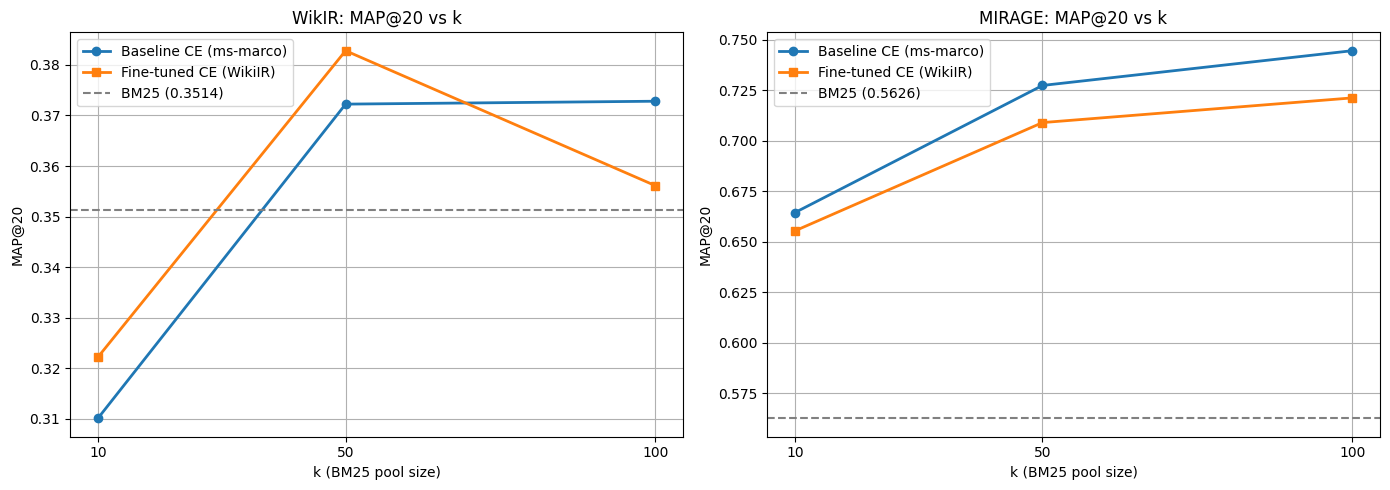

In [26]:
# Визуализация: MAP@20 по k для baseline vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['WikIR', 'MIRAGE']):
    k_vals = RERANK_K_VALUES
    baseline_maps = [results.get(f'Baseline CE k={k}', {}).get(dataset, {}).get('MAP@20', 0) for k in k_vals]
    finetuned_maps = [results.get(f'Fine-tuned CE k={k}', {}).get(dataset, {}).get('MAP@20', 0) for k in k_vals]
    bm25_map = results['BM25'][dataset].get('MAP@20', 0)

    ax.plot(k_vals, baseline_maps,  marker='o', label='Baseline CE (ms-marco)', linewidth=2)
    ax.plot(k_vals, finetuned_maps, marker='s', label='Fine-tuned CE (WikiIR)', linewidth=2)
    ax.axhline(bm25_map, linestyle='--', color='gray', label=f'BM25 ({bm25_map:.4f})')

    ax.set_xlabel('k (BM25 pool size)')
    ax.set_ylabel('MAP@20')
    ax.set_title(f'{dataset}: MAP@20 vs k')
    ax.set_xticks(k_vals)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('map_comparison.png', dpi=150)
plt.show()

## 8. Анализ результатов

WikIR (k=100)

| Метрика | BM25 | Baseline CE | Fine-tuned CE | Δ (FT − Base) |
|---------|------|-------------|---------------|----------------|
| MAP@20 | 0.3514 | 0.3728 | 0.3561 | −0.0167 |
| P@1 | 0.8100 | 0.9200 | 0.9000 | −0.0200 |


MIRAGE (k=100)

| Метрика | BM25 | Baseline CE | Fine-tuned CE | Δ (FT − Base) |
|---------|------|-------------|---------------|----------------|
| MAP@20 | 0.5626 | 0.7445 | 0.7212 | −0.0234 |
| P@1 | 0.4865 | 0.7044 | 0.6708 | −0.0336 |

Fine-tuned cross-encoder уступает baseline (ms-marco) на обоих датасетах, включая WikIR, на котором он непосредственно обучался. Возможные причины:

- Негативы формировались случайной выборкой из BM25 top-100. На практике они оказались недостаточно трудными: модель быстро научилась их отличать от позитивов, о чём свидетельствует резкое падение лосса уже ко второй эпохе (0.368 → 0.180). 

- Отсутствие валидации и ранней остановки и, как следствие, переобучение. Обучение проводилось ровно 3 эпохи, модель сохранялась после последней без отбора лучшего чекпоинта по валидационной метрике. К третьей эпохе лосс продолжал снижаться (0.180 → 0.141), что при слабых негативах скорее указывает на запоминание обучающих пар, чем на улучшение обобщения. В результате модель частично утратила общую способность к реранжированию, накопленную при предобучении на ms-marco, не приобретя взамен ничего нового. Ухудшение на MIRAGE - это следствие той же деградации, модель стала хуже в целом.